# <span style="color:darkorange"> Demos autoencoders

This demo is based on  https://blog.keras.io/building-autoencoders-in-keras.html

# <span style="color:darkorange"> Undercomplete autoencoder with MNIST (compression)

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.preprocessing import OneHotEncoder
from sklearn import preprocessing

import matplotlib.image as mpimg
from skimage.io import imread, imshow
from skimage import data, color, io, filters, morphology,transform, exposure, feature, util
from scipy import ndimage

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Activation
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.layers import Input, Dense, Dropout, Flatten, BatchNormalization
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras import backend as K
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing import image
from tensorflow.keras import regularizers



###### Check Tensorflow-GPU ########

#physical_devices = tf.config.experimental.list_physical_devices('GPU')
#tf.config.experimental.set_memory_growth(physical_devices[0], True)

import warnings
warnings.filterwarnings('ignore')

#### <span style="color:deeppink"> Preprocessing the dataset

In [2]:
# Loading dataset
df_train = pd.read_csv('train.csv')
df_test = pd.read_csv('test.csv')

X_train = df_train.drop('label',axis=1).values
X_test  = df_test.drop('label',axis=1).values

# normalize the dataset
X_train = X_train.astype('float32') / 255.
X_test = X_test.astype('float32') / 255.


#### <span style="color:deeppink"> Building the autoencoder

In [3]:
# Functional model

# 1️⃣ Set the size of the "bottleneck" (encoded) layer
encoding_dim = 64  # -> We'll compress 784 input numbers (pixels) down to 64 numbers.

# 2️⃣ Define the input layer
input_img = Input(shape=(784,)) # -> Each image is flattened into a 1D vector of 784 numbers

# 3️⃣ Define the encoder layer
encoded = Dense(encoding_dim, activation='relu')(input_img) # -> This layer takes the input and produces a smaller, 64-number representation, with 'relu' as the activation function

# 4️⃣ Define the decoder layer
decoded = Dense(784, activation='sigmoid')(encoded) # -> This layer tries to reconstruct the original 784 numbers from the 64 encoded ones.

# 5️⃣ Combine encoder + decoder into one full autoencoder model
# build autoencoder 
autoencoder = Model(inputs=input_img, outputs=decoded) # -> The model takes an image, encodes it, and then decodes it back.


autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 784)            │        50,960 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,200 (395.31 KB)

 Trainable params: 101,200 (395.31 KB)

 Non-trainable params: 0 (0.00 B)

#### <span style="color:deeppink"> Build a separate encoder & decoder

Let's now create a separate model for the  
- encoder (to get the compressed representations)
- the decoder (to reconstruct the data from the compressed representations)

This will allow us later on to visualise the compressions

In [4]:
# 1️⃣ Create the ENCODER model
#    So if you pass an image through 'encoder.predict()', you’ll get its compressed version!
encoder = Model(input_img, encoded) # -> This new model starts with the same input (784 numbers) and outputs only the encoded representation (64 numbers).

# 2️⃣ Create the DECODER model
# Step 1: Define a new input for the decoder
encoded_input = Input(shape=(encoding_dim,)) # -> This says: "I’ll feed you a 64-number encoded vector."

# Step 2: Grab the last layer (decoder layer) from the autoencoder
decoder_layer = autoencoder.layers[-1] # -> 'autoencoder.layers' is a list of all layers in the model.

# Step 3: Build the decoder model using that layer
decoder = Model(inputs=encoded_input, outputs=decoder_layer(encoded_input))
# -> This new model starts from a 64-number input,
#    passes it through the final decoding layer,
#    and outputs the reconstructed 784-number image.


# 3️⃣ Compile the AUTOENCODER model
# Option A: Use mean squared error (MSE)
autoencoder.compile(optimizer='adam', loss='mean_squared_error')

# Option B: Use binary cross-entropy
#autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

#### <span style="color:deeppink"> Train the autoencoder

In [5]:
epochs = 50
batchsize = 256

autoencoder.fit(X_train, X_train, # in an autoencoder the input and the output are the same
                epochs=epochs,
                batch_size=batchsize,
                shuffle=True)

Epoch 1/50
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1245
Epoch 2/50
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0427
Epoch 3/50
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0311
Epoch 4/50
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0243
Epoch 5/50
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0200
Epoch 6/50
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0170
Epoch 7/50
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0147
Epoch 8/50
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0129
Epoch 9/50
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0114
Epoch 10/50
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0102
Epoch 11/50
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0092
Epoch 12/50
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0084
Epoch 13/50
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0076
Epoch 14/50
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0071
Epoch 15/50
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - lo

#### <span style="color:deeppink"> Testing the encoder 
Take your test dataset X_test (each sample is a flattened image with 784 values).  
Passes it through the encoder network only.  
Produces encoded_imgs, which is a compressed representation of the input —>  
each sample now has only 64 numbers instead of 784.  

In [6]:
# Testing
encoded_imgs = encoder.predict(X_test)

375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 273us/step


#### <span style="color:deeppink"> Testing the decoder
Take those 64-number encoded vectors.  
Feed them into the decoder model.  
Reconstructs outputs that try to look like the original 784-number input images.  

In [7]:
decoded_imgs = decoder.predict(encoded_imgs)

375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 305us/step


#### <span style="color:deeppink"> Visualizing original vs. reconstructed images  
Now that the autoencoder has generated reconstructions (`decoded_imgs`),  
let’s compare them with the original test images (`X_test`) side-by-side.

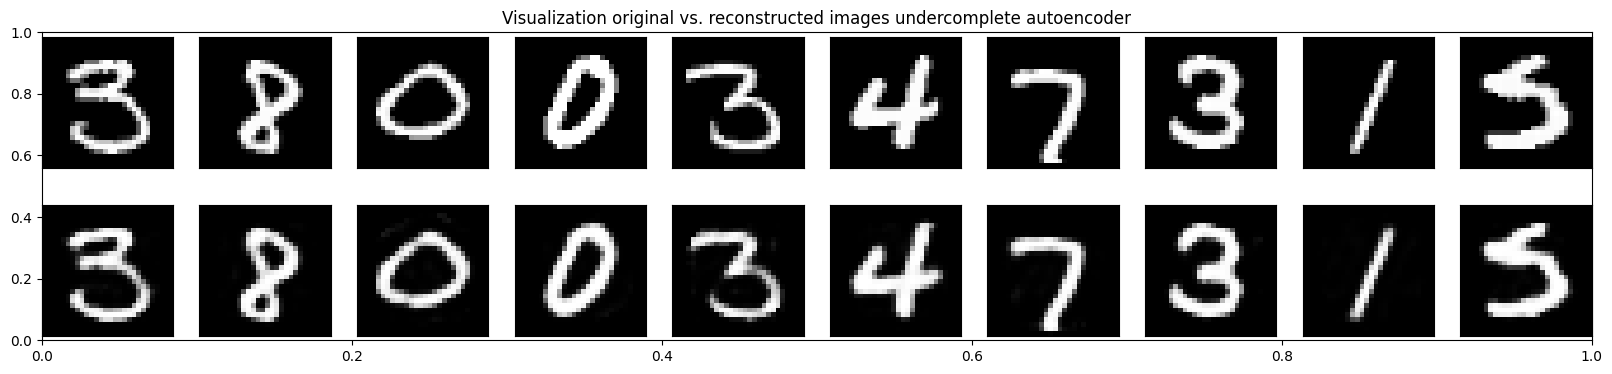

In [8]:
n = 10 # Number of images to show
plt.figure(figsize=(20, 4))
plt.title("Visualization original vs. reconstructed images undercomplete autoencoder")
for i in range(n):
    # Display the Original Image
    ax = plt.subplot(2, n, i + 1) # Create subplot in the top row
    plt.imshow(X_test[i].reshape(28, 28)) # Reshape 784 → 28x28 pixels
    plt.gray() # Show image in grayscale
    ax.get_xaxis().set_visible(False) # Hide X-axis ticks
    ax.get_yaxis().set_visible(False) # Hide Y-axis ticks

    # Display the Reconstructed Image
    ax = plt.subplot(2, n, i + 1 + n) # Create subplot in the bottom row
    plt.imshow(decoded_imgs[i].reshape(28, 28)) # Reshape 784 → 28x28 pixels
    plt.gray() # Show image in grayscale
    ax.get_xaxis().set_visible(False) # Hide X-axis ticks
    ax.get_yaxis().set_visible(False) # Hide Y-axis ticks

plt.show()

#### <span style="color:deeppink"> Visualizing original vs. compressed images
The encoder compresses each input image (28×28 pixels = 784 values) into a smaller 64-dimensional vector.

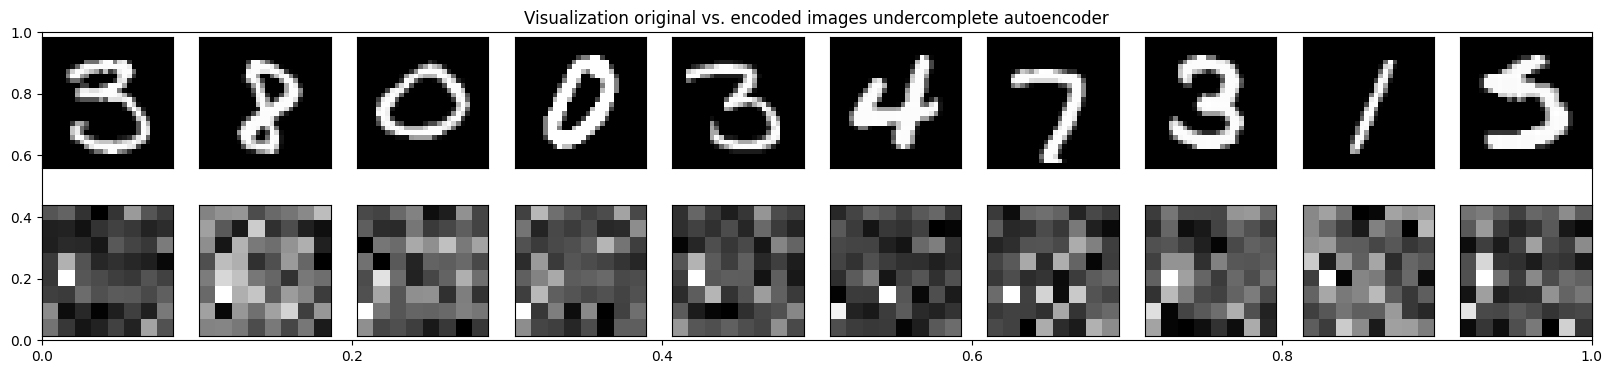

In [9]:
# Compression visualization

n = 10 # number of images to plot
plt.figure(figsize=(20, 4))
plt.title("Visualization original vs. encoded images undercomplete autoencoder")
for i in range(n):
    # Original Images (Top Row)
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(X_test[i].reshape(28, 28)) # Reshape 784 → 28x28
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Encoded Representations (Bottom Row)
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(encoded_imgs[i].reshape(8, 8))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)


plt.show()

# <span style="color:darkorange"> Deep undercomplete autoencoder
Instead of a single layer encoder/decoder, this autoencoder uses multiple layers, which allows it to learn more complex features from the data.  
- Encoder module: compresses 784 → 128 → 64 → 32  
- Decoder module: expands 32 → 64 → 128 → 784


In [10]:
# Full image input (flattened)
input_img = Input(shape=(784,))  

# Input for decoder (encoded representation)
encoded_img = Input(shape=(32,))

# Encoder Module (Multiple Layers)
def encoder_module(x):
    encoded = Dense(128, activation='relu')(x) # First compression layer
    encoded = Dense(64, activation='relu')(encoded) # Second compression layer
    encoded = Dense(32, activation='relu')(encoded) # Bottleneck layer (final compressed code)
    return encoded

# Decoder Module (Multiple Layers)
def decoder_module(x):
    decoded = Dense(64, activation='relu')(x) # First expansion layer 
    decoded = Dense(128, activation='relu')(decoded) # Second expansion layer
    decoded = Dense(784, activation='sigmoid')(decoded) # Reconstruct to original size
    return decoded

# Create Separate Encoder and Decoder Models
encoder = Model(inputs=input_img, outputs=encoder_module(input_img))
decoder = Model(inputs=encoded_img, outputs=decoder_module(encoded_img))



#### <span style="color:deeppink"> Combine encoder + decoder into one Model:
`autoencoder = Model(inputs=input_img, outputs=decoder(encoder(input_img)))`
Let's focus on the outputs variable:  
encoder(input_img)  
→ Sends the input image through the encoder network.  
→ Output: compressed (encoded) features.  

decoder(...)  
→ Takes the encoded features and sends them through the decoder network.  
→ Output: reconstructed (decoded) image.  

Together:
`input_img → encoder → decoder → reconstructed image`  

So `decoder(encoder(input_img))` literally connects the two models together.


In [11]:
# Combine Encoder + Decoder into Autoencoder
autoencoder = Model(inputs=input_img, outputs=decoder(encoder(input_img)))
autoencoder.summary()
#autoencoder.compile(optimizer='adam', loss='binary_crossentropy')
autoencoder.compile(optimizer='adam',loss='mean_squared_error')


Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ functional_3 (Functional)       │ (None, 32)             │       110,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ functional_4 (Functional)       │ (None, 784)            │       111,568 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 222,384 (868.69 KB)

 Trainable params: 222,384 (868.69 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
autoencoder.fit(X_train, X_train, # Inputs and targets are the same for autoencoders
                epochs=100,
                batch_size=256,
                shuffle=True)


Epoch 1/100
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1163
Epoch 2/100
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0491
Epoch 3/100
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0360
Epoch 4/100
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0284
Epoch 5/100
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0247
Epoch 6/100
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0229
Epoch 7/100
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0213
Epoch 8/100
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0200
Epoch 9/100
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0190
Epoch 10/100
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0185
Epoch 11/100
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0178
Epoch 12/100
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0173
Epoch 13/100
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0169
Epoch 14/100
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0164
Epoch 15/100
118/118 ━━━━━━━━━━━━━━━━━━━━ 0

In [13]:
# Testing
encoded_imgs = encoder.predict(X_test)
print(encoded_imgs.shape)
decoded_imgs = decoder.predict(encoded_imgs)

375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 402us/step
(12000, 32)
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 357us/step


#### <span style="color:deeppink"> Visualizing original vs. compressed images vs results

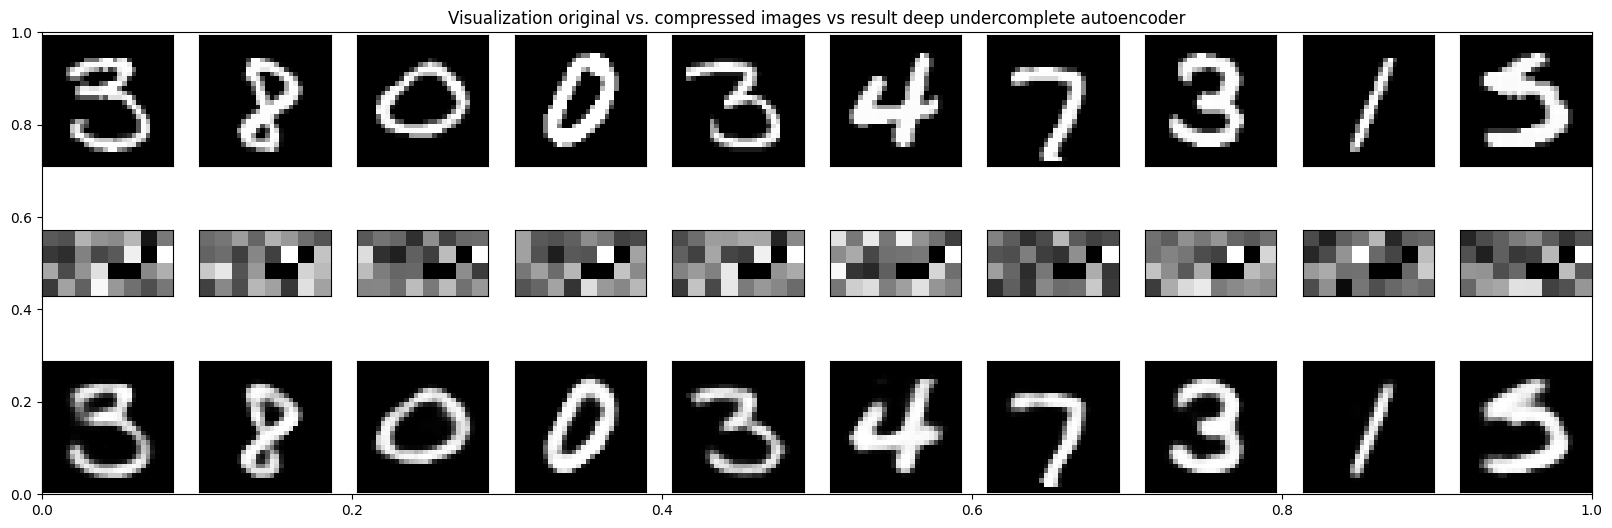

In [14]:
# visualisation

n = 10 # number of images to plot
plt.figure(figsize=(20, 6))
plt.title("Visualization original vs. compressed images vs result deep undercomplete autoencoder")
for i in range(n):
    # Originals
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(X_test[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    #encoded values
    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(encoded_imgs[i].reshape(4, 8)) # 32 features reshaped to 4x8
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    
    # Reconstructions
    ax = plt.subplot(3, n, i + 1 + 2*n)
    plt.imshow(decoded_imgs[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()

# <span style="color:darkorange"> Undercomplete convolutional autoencoder
A convolutional autoencoder compresses images using Conv2D + Pooling layers (encoder) and reconstructs them using Conv2D + UpSampling layers (decoder).  

In [15]:
from tensorflow.keras.layers import Input, Dense, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.models import Model

#Encoder
input_img = Input(shape=(28, 28, 1))  # Grayscale image input (28x28 pixels, 1 channel)

# First convolution + pooling
x = Conv2D(16, (3, 3), activation='relu', padding='same')(input_img)
x = MaxPooling2D((2, 2), padding='same')(x) # Reduce spatial dimensions by 2

# Second convolution + pooling
x = Conv2D(8, (3, 3), activation='relu', padding='same')(x)
x = MaxPooling2D((2, 2), padding='same')(x)

# Third convolution + pooling (final compressed representation)
x = Conv2D(8, (3, 3), activation='relu', padding='same')(x)
encoder = MaxPooling2D((2, 2), padding='same')(x) # Bottleneck

# Decoder

# First convolution + upsampling
x = Conv2D(8, (3, 3), activation='relu', padding='same')(encoder)
x = UpSampling2D((2, 2))(x)

# Second convolution + upsampling
x = Conv2D(8, (3, 3), activation='relu', padding='same')(x)
x = UpSampling2D((2, 2))(x)

# Third convolution + upsampling
x = Conv2D(16, (3, 3), activation='relu')(x)
x = UpSampling2D((2, 2))(x)

# Output layer: reconstruct original 28x28 image
decoder = Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)

# Build and Compile Autoencoder
autoencoder = Model(inputs=input_img, outputs=decoder)
#autoencoder.compile(optimizer='adam', loss='mean_squared_error')
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')
autoencoder.summary()

Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 8)      │         1,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 8)        │           584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 4, 4, 8)        │           584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 8, 8, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 8)        │           584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 16, 16, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 14, 14, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_2 (UpSampling2D)  │ (None, 28, 28, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 1)      │           145 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,385 (17.13 KB)

 Trainable params: 4,385 (17.13 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
# Reshape data to match Conv2D input: (samples, height, width, channels)
X_train = np.reshape(X_train, (len(X_train), 28, 28, 1)) 
X_test = np.reshape(X_test, (len(X_test), 28, 28, 1)) 

In [17]:
# Train the autoencoder 
autoencoder.fit(X_train, X_train, # Inputs = outputs for autoencoders
                epochs=10,
                batch_size=128,
                shuffle=True)

Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - loss: 0.3979
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - loss: 0.1674
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 0.1494
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 0.1385
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 0.1311
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - loss: 0.1261
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 0.1223
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 0.1192
Epoch 9/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 0.1174
Epoch 10/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - loss: 0.1155


#### <span style="color:deeppink"> Visualize original vs reconstructed images

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


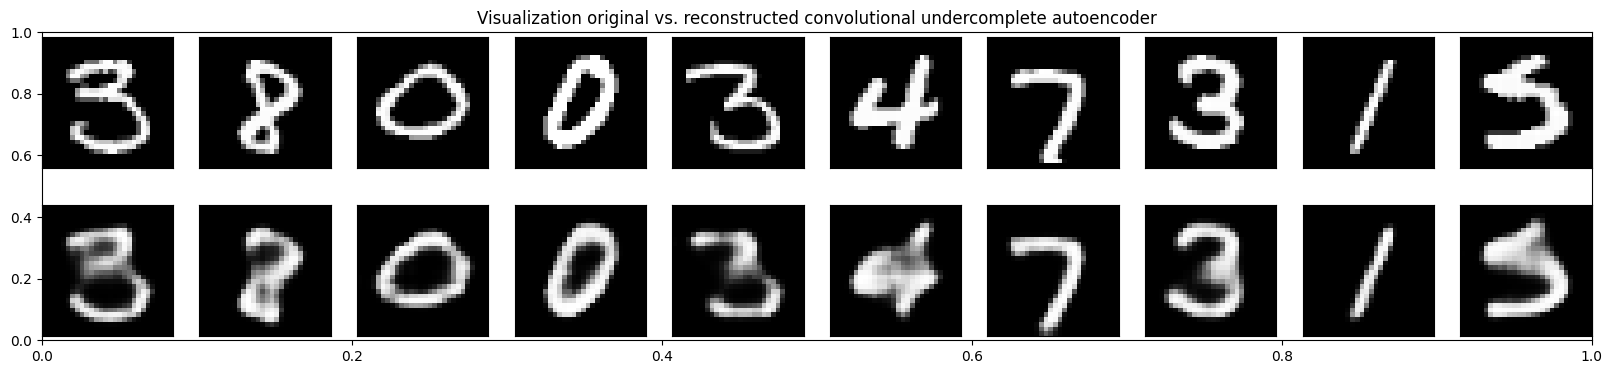

In [18]:
# Testing

# reconstruct images from test data
decoded_imgs = autoencoder.predict(X_test)

n = 10 # number of images to plot
plt.figure(figsize=(20, 4))
plt.title("Visualization original vs. reconstructed convolutional undercomplete autoencoder")
for i in range(n):
    # Originals
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(X_test[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Reconstructions
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()



# <span style="color:darkorange"> Overcomplete sparse autoencoder  
This overcomplete autoencoder adds L1 activity regularization to the hidden layer.  
Regularization encourages the network to produce sparse activations — only a few neurons “fire” for each input.  
This prevents overfitting in the overcomplete autoencoder.

In [19]:
# Load CSV data
df_train = pd.read_csv('train.csv')
df_test = pd.read_csv('test.csv')

# Separate features and labels
X_train = df_train.drop('label',axis=1).values
X_test  = df_test.drop('label',axis=1).values

# Normalize pixel values to [0,1]
X_train = X_train.astype('float32') / 255.
X_test = X_test.astype('float32') / 255.

# build overcomplete autoencoder
encoding_dim = 900 # Hidden layer size -> bigger than input size

# Input layer
input_img = Input(shape=(784,))

# Encoder: Dense layer with L1 activity regularization
encoded = Dense(encoding_dim, activation='relu',
                activity_regularizer=regularizers.l1(10e-7))(input_img)
# Decoder: reconstruct original image
decoded = Dense(784, activation='sigmoid')(encoded)

# Full autoencoder model
autoencoder = Model(inputs=input_img, outputs=decoded)


#### <span style="color:deeppink"> Separate encoder and decoder models

In [20]:
# Encoder model
encoded_input = Input(shape=(encoding_dim,))

# Decoder model
# Get the last layer
decoder_layer = autoencoder.layers[-1]

# Create a separte encoder and decoder model
encoder = Model(inputs=input_img, outputs=encoded)
decoder = Model(inputs=encoded_input, outputs=decoder_layer(encoded_input))

# Compilation
autoencoder.compile(optimizer='adam', loss='mean_squared_error')
# Optional: binary_crossentropy could also be used
#autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

In [21]:
epochs = 30 # More epochs needed due to regularization
batchsize = 256
autoencoder.fit(X_train, X_train,
                epochs=epochs,
                batch_size=batchsize,
                shuffle=True)

Epoch 1/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.1194
Epoch 2/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0399
Epoch 3/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0292
Epoch 4/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0247
Epoch 5/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0219
Epoch 6/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0203
Epoch 7/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0189
Epoch 8/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0179
Epoch 9/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0171
Epoch 10/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0164
Epoch 11/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0157
Epoch 12/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0152
Epoch 13/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0147
Epoch 14/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0143
Epoch 15/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/s

In [22]:
# Testing
encoded_imgs = encoder.predict(X_test)
decoded_imgs = decoder.predict(encoded_imgs)

375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 504us/step
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 545us/step


#### <span style="color:deeppink"> Visualize original vs reconstructed images sparse autoencoder

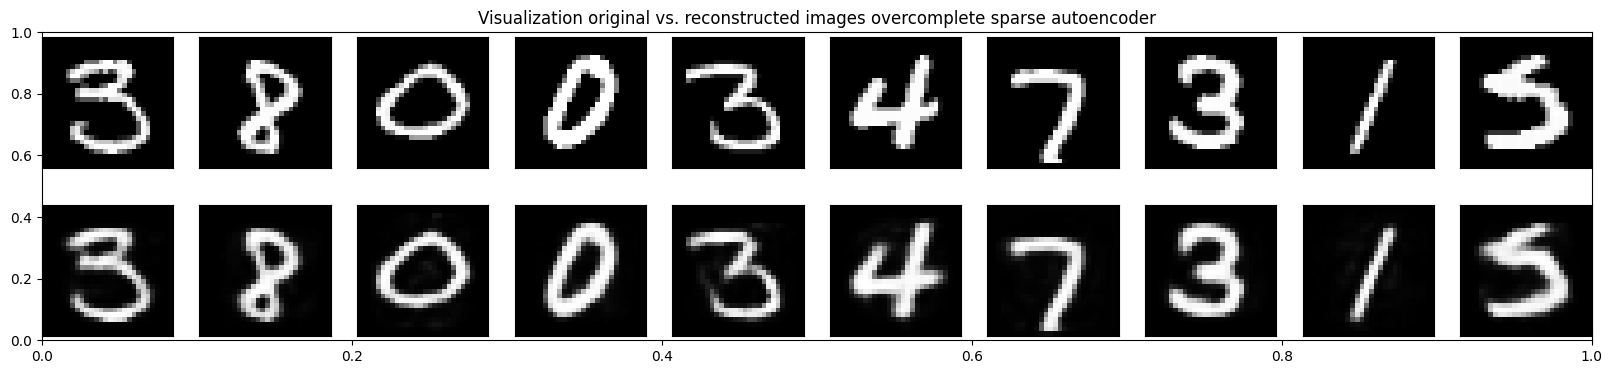

In [23]:
n = 10  # 
plt.figure(figsize=(20, 4))
plt.title("Visualization original vs. reconstructed images overcomplete sparse autoencoder")
for i in range(n):
    # Originals
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(X_test[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Reconstructions
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()

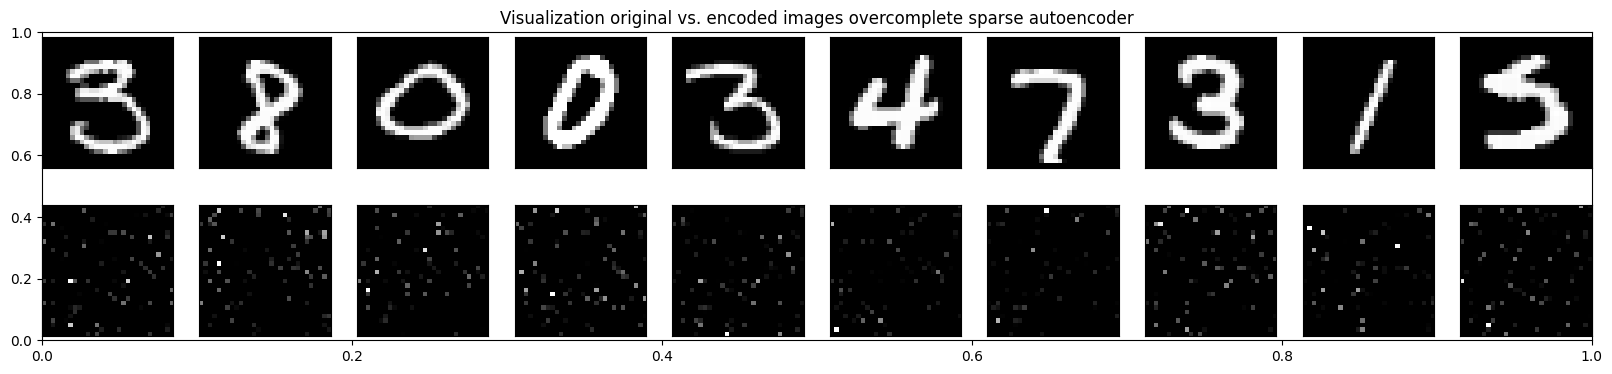

In [24]:
# Visualization

n = 10 
plt.figure(figsize=(20, 4))
plt.title("Visualization original vs. encoded images overcomplete sparse autoencoder")
for i in range(n):
    # Originals
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(X_test[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Visualization of encoded images
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(encoded_imgs[i].reshape(30, 30))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()

# <span style="color:darkorange"> Overcomplete denoising autoencoder  
A denoising autoencoder is trained to remove noise from inputs:  
- Input: Noisy image (`X_train_noisy`)
- Target/Output: Clean image (`X_train`)

The network learns to reconstruct clean images from noisy versions, improving robustness.

In [25]:
# Load CSV data
df_train = pd.read_csv('train.csv')
df_test = pd.read_csv('test.csv')

# Separate features and labels
X_train = df_train.drop('label',axis=1).values
X_test  = df_test.drop('label',axis=1).values

# Normalize pixel values to [0,1]
X_train = X_train.astype('float32') / 255.
X_test = X_test.astype('float32') / 255.


#### <span style="color:deeppink"> Add noise to images
`noise_factor` controls how noisy the input becomes.

In [26]:
# Adding some level of noise

noise_factor = 0.5

# Add Gaussian noise
X_train_noisy = X_train + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=X_train.shape) 
X_test_noisy = X_test + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=X_test.shape) 

# noise clipping
X_train_noisy = np.clip(X_train_noisy, 0., 1.)
X_test_noisy = np.clip(X_test_noisy, 0., 1.)

#### <span style="color:deeppink"> Visualize noisy images  
Show a few noisy images to see the effect of noise.

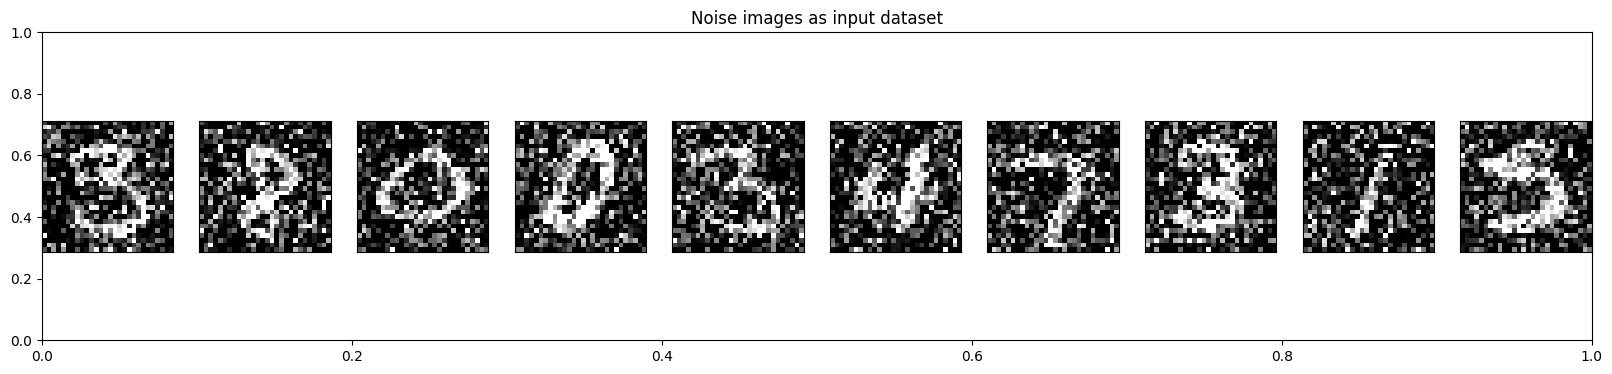

In [27]:
# Visualizatoin

n = 10
plt.figure(figsize=(20, 4))
plt.title("Noise images as input dataset")
for i in range(n):
    ax = plt.subplot(1, n, i+1)
    plt.imshow(X_test_noisy[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()

In [28]:
# Overcomplete autoencoder
encoding_dim = 900  # Larger than input → overcomplete

# Input layer
input_img = Input(shape=(784,))

# Encoder (overcomplete, no regularization here)
encoded = Dense(encoding_dim, activation='relu')(input_img)

# Decoder
decoded = Dense(784, activation='sigmoid')(encoded)

# Full autoencoder
autoencoder = Model(inputs=input_img, outputs=decoded)

# Separate encoder and decoder models
encoded_input = Input(shape=(encoding_dim,))
# get the last layer
decoder_layer = autoencoder.layers[-1]

encoder = Model(input_img, encoded)
decoder = Model(encoded_input, decoder_layer(encoded_input))

autoencoder.compile(optimizer='adam', loss='mean_squared_error')
#autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

epochs = 30 # meer epochs omdat het model geregulariseerd wordt
batchsize = 256
autoencoder.fit(X_train_noisy, X_train, # Input = noisy, target = clean
                epochs=epochs,
                batch_size=batchsize,
                shuffle=True)



Epoch 1/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0799
Epoch 2/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0326
Epoch 3/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0260
Epoch 4/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0231
Epoch 5/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0202
Epoch 6/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0181
Epoch 7/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0166
Epoch 8/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0153
Epoch 9/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0146
Epoch 10/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0141
Epoch 11/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0137
Epoch 12/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0133
Epoch 13/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0130
Epoch 14/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0127
Epoch 15/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - 

In [29]:
# Testing
encoded_imgs = encoder.predict(X_test_noisy)
decoded_imgs = decoder.predict(encoded_imgs)

375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 483us/step
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 519us/step


#### <span style="color:deeppink"> Visualize noisy vs denoised test images

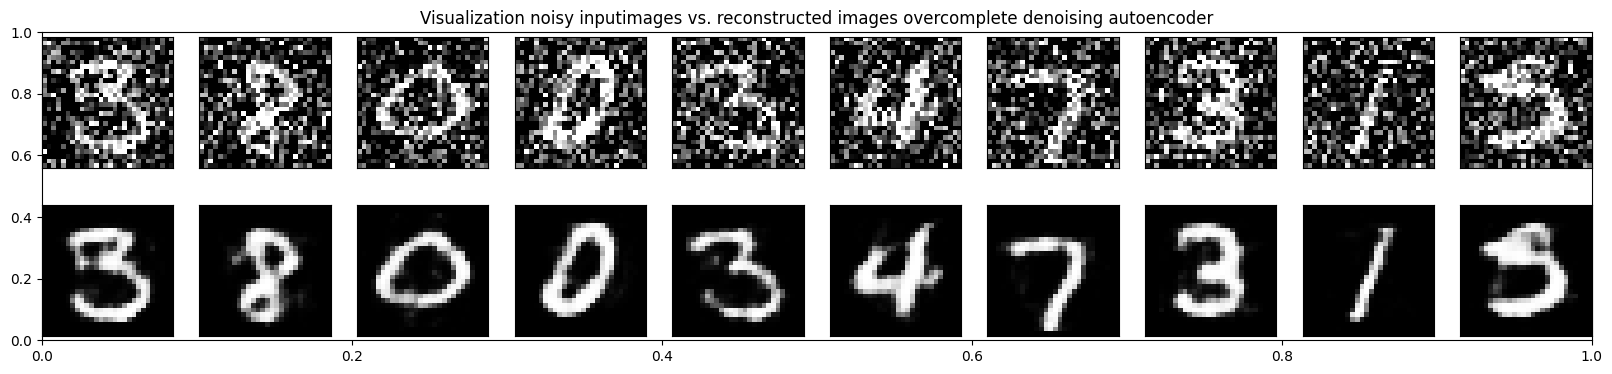

In [30]:
n = 10  
plt.figure(figsize=(20, 4))
plt.title("Visualization noisy inputimages vs. reconstructed images overcomplete denoising autoencoder")
for i in range(n):
    # Noisy input
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(X_test_noisy[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Denoised reconstruction
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()

# <span style="color:darkorange"> Denoising convolutional autoencoder
A convolutional denoising autoencoder:  
Takes noisy images as input (X_train_noisy).  
Learns to reconstruct clean images (X_train).  

In [31]:
input_img = Input(shape=(28, 28, 1))  # Grayscale image input

# Encoder: compresses image from 28×28×1 → 7×7×32
x = Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
x = MaxPooling2D((2, 2), padding='same')(x)
x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
encoded = MaxPooling2D((2, 2), padding='same')(x)


# Decoder: reconstructs the image back to 28×28×1

x = Conv2D(32, (3, 3), activation='relu', padding='same')(encoded)
x = UpSampling2D((2, 2))(x)
x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = UpSampling2D((2, 2))(x)
decoded = Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)

autoencoder = Model(inputs=input_img, outputs=decoded)
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

X_train = np.reshape(X_train, (len(X_train), 28, 28, 1)) 
X_train_noisy = np.reshape(X_train_noisy, (len(X_train), 28, 28, 1)) 
X_test = np.reshape(X_test, (len(X_test), 28, 28, 1)) 
X_test_noisy = np.reshape(X_test_noisy, (len(X_test_noisy), 28, 28, 1)) 

autoencoder.fit(X_train_noisy, X_train,
                epochs=100,
                batch_size=128)


Epoch 1/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 8s 31ms/step - loss: 0.3179
Epoch 2/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 8s 35ms/step - loss: 0.1246
Epoch 3/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 9s 38ms/step - loss: 0.1150
Epoch 4/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 8s 36ms/step - loss: 0.1102
Epoch 5/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 31ms/step - loss: 0.1072
Epoch 6/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 9s 39ms/step - loss: 0.1057
Epoch 7/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 32ms/step - loss: 0.1048
Epoch 8/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 9s 37ms/step - loss: 0.1032
Epoch 9/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 31ms/step - loss: 0.1022
Epoch 10/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 31ms/step - loss: 0.1015
Epoch 11/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 31ms/step - loss: 0.1009
Epoch 12/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 31ms/step - loss: 0.1003
Epoch 13/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 8s 32ms/step - loss: 0.1000
Epoch 14/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 8s 32ms/step - loss: 0.0997
Epoch 15/100
235/235 ━━━━━━━━

375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


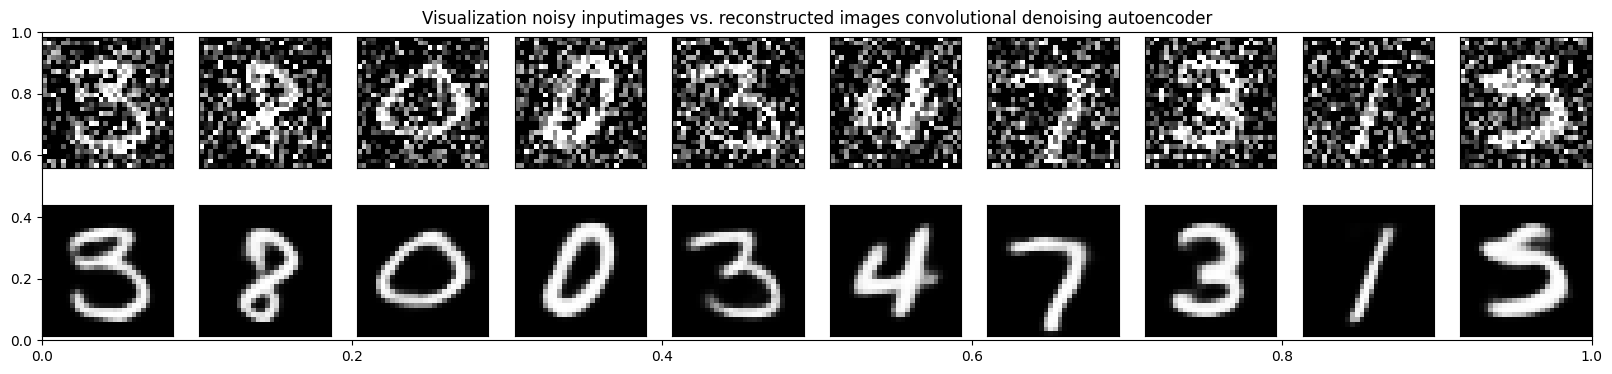

In [32]:
# Testing

decoded_imgs = autoencoder.predict(X_test_noisy)

n = 10 #aantal te tonen afbeeldingen
plt.figure(figsize=(20, 4))
plt.title("Visualization noisy inputimages vs. reconstructed images convolutional denoising autoencoder")
for i in range(n):
    # Noisy input
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(X_test_noisy[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Denoised reconstruction
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()